# Finite Element Solution of a Coupled Drug Diffusion–Reaction Model

## Objective
- Linear finite elements for spatial discretization.
- Backward Euler for time integration.
- NumPy for matrix operations.
- SciPy for solving linear systems.
- Matplotlib for visualization.

## Physical Problem

The model describes three interacting quantities inside a drug delivery
material:

- **u(x,t)** : free drug concentration
- **v(x,t)** : bound drug concentration
- **s(x,t)** : mechanical stress

The interaction between diffusion, binding, and stress determines how
the drug is released over time.

---

## Numerical Method

The numerical solution consists of two stages.

### Spatial discretization

The spatial domain is divided into finite elements.

Each unknown is approximated using piecewise linear basis functions.

This converts the PDEs into a system of ordinary differential equations.

### Time discretization

The resulting ODE system is integrated using the Backward Euler method.

At every time step a linear system is solved.

This combination

> FEM in space + Backward Euler in time

is one of the most common approaches for diffusion-reaction problems.

## Import Required Libraries

Only four scientific Python libraries are required.

- NumPy
  - numerical arrays
  - linear algebra

- SciPy
  - sparse matrix solver

- Matplotlib
  - plotting

No specialized FEM library (such as FEniCS or SfePy) is used.

In [70]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve

## Weak Formulation

The finite element method does not solve the strong form of the partial
differential equations directly.

Instead, each equation is converted into its **weak (variational) form**.

This process reduces the differentiability requirements of the solution
and naturally introduces the stiffness matrix that characterizes FEM.



### Step 1: Strong Form

The governing equation for the free drug concentration is

### Step 2: Multiply by a Test Function

### Step 3: Integration by Parts

The diffusion terms contain second derivatives.

The same procedure is applied to the stress diffusion term.

This is the key mathematical step of FEM.

Notice that the second derivative disappears.

Only first derivatives remain.

### Why is this important?

After the weak form has been obtained,

every integral can be approximated over each finite element.

Doing so naturally produces two matrices

- Mass Matrix
- Stiffness Matrix

which form the backbone of every finite element algorithm.

### Model Parameters and Mesh


For linear one-dimensional elements,

each element has

- two nodes,
- two basis functions.

If the mesh contains
\[
N
\]nodes,then the number of elements is
\[
N-1.
\]

Increasing the number of elements generally improves the numerical
accuracy but increases the computational cost.

In [71]:
# Physical Parameters

D = 0.6          # Drug diffusion coefficient
E = 0.2          # Stress diffusion coefficient

alpha = 0.2      # Stress generation
beta = 1.0       # Stress relaxation
gamma = 1.0      # Coupling parameter

ub = 1.0
vb = 1.0

kr = 1.0         # Robin boundary coefficient
ua = 0.0         # External drug concentration

# Spatial Domain

x_start = -0.5
x_end = 0.5

# Number of nodes
num_nodes = 51

# Number of finite elements
num_elements = num_nodes - 1

# Uniform mesh
x = np.linspace(x_start, x_end, num_nodes)

# Element length
h = x[1] - x[0]

print("Mesh Information")
print(f"Nodes      : {num_nodes}")
print(f"Elements   : {num_elements}")
print(f"Element h  : {h:.5f}")

Mesh Information
Nodes      : 51
Elements   : 50
Element h  : 0.02000


# Element Mass Matrix and Element Stiffness Matrix

In the previous sections, we discretized the physical domain into finite elements. The next step in the Finite Element Method (FEM) is to compute the **element matrices**, which describe the behavior of each individual element.

For a one-dimensional linear element, two matrices are required:

- **Element Mass Matrix** ($M_e$)
- **Element Stiffness Matrix** ($K_e$)

These matrices are computed once (for a uniform mesh) and later assembled into the global system.

---

## 1. Element Mass Matrix

The governing equations of this problem are **time-dependent**, containing terms such as

$$
\frac{\partial u}{\partial t}.
$$

After applying the weighted residual (Galerkin) method and substituting the finite element approximation

$$
u_h(x,t)=N(x)\mathbf{U}(t),
$$

the time derivative becomes

$$
\frac{\partial u_h}{\partial t}
=
N(x)\frac{d\mathbf{U}}{dt}.
$$

Substituting this into the weak form produces the **element mass matrix**

$$
M_e=\int_{\Omega_e} N^TN\,dx.
$$

For a two-node linear element of length $h$, evaluating this integral gives

$$
M_e=
\frac{h}{6}
\begin{bmatrix}
2 & 1\\
1 & 2
\end{bmatrix}.
$$

The mass matrix represents the **storage (or accumulation)** of the unknown variable within each element. Since this problem is transient, the mass matrix is required to describe how the solution evolves with time.

---

## 2. Element Stiffness Matrix

The diffusion term in the governing equation contains the second spatial derivative

$$
\frac{\partial^2u}{\partial x^2}.
$$

After integration by parts, the weak form contains only first derivatives,

$$
\int_{\Omega_e}
\frac{dN}{dx}^T
\frac{dN}{dx}
\,dx.
$$

Defining

$$
B=\frac{dN}{dx},
$$

the element stiffness matrix is

$$
K_e=
\int_{\Omega_e}
B^TB\,dx.
$$

For a two-node linear element,

$$
K_e=
\frac{1}{h}
\begin{bmatrix}
1 & -1\\
-1 & 1
\end{bmatrix}.
$$

The stiffness matrix represents the **diffusion (or resistance)** between neighboring nodes. It controls how the solution varies spatially across the element.

---

## Why are both matrices needed?

Unlike steady-state problems, this model contains both:

- **Time-dependent terms** → represented by the **Mass Matrix** ($M_e$)
- **Spatial diffusion terms** → represented by the **Stiffness Matrix** ($K_e$)

Therefore, both matrices are required when constructing the finite element formulation of the governing PDEs.

---

In the following code cell, the functions `element_mass_matrix(h)` and `element_stiffness_matrix(h)` compute these matrices for a linear element of length `h`. Since the mesh is uniform, these matrices are identical for every element and only need to be computed once before the global assembly process.

In [72]:
# Element Matrices

def element_mass_matrix(h):

    Me = (h / 6.0) * np.array([
        [2.0, 1.0],
        [1.0, 2.0]
    ])
    return Me


def element_stiffness_matrix(h):

    Ke = (1.0 / h) * np.array([
        [1.0, -1.0],
        [-1.0, 1.0]
    ])
    return Ke


# Compute the matrices for the current mesh
Me = element_mass_matrix(h)
Ke = element_stiffness_matrix(h)

print("Element Mass Matrix")
print(Me)
print("\nElement Stiffness Matrix")
print(Ke)

Element Mass Matrix
[[0.00666667 0.00333333]
 [0.00333333 0.00666667]]

Element Stiffness Matrix
[[ 50. -50.]
 [-50.  50.]]


# Global Matrix Assembly

The element mass matrix ($M_e$) and element stiffness matrix ($K_e$) describe the behavior of **a single finite element**. However, the physical domain consists of many connected elements that share common nodes.

To represent the behavior of the **entire domain**, the local element matrices must be assembled into two global matrices:

- Global Mass Matrix ($M$)
- Global Stiffness Matrix ($K$)

---

## Why is Assembly Needed?

Each finite element contributes only to the nodes that belong to that element.

For example, in a one-dimensional mesh

```
Node 1 ---- Node 2 ---- Node 3 ---- Node 4
   E1          E2          E3
```

- Element 1 contributes to Nodes (1,2)
- Element 2 contributes to Nodes (2,3)
- Element 3 contributes to Nodes (3,4)

Notice that Nodes 2 and 3 are shared by neighboring elements.

Since there is only **one physical solution** at each shared node, the contributions from all connected elements must be **added together**.

This process is called **assembly**.

---

## Connectivity

For a two-node linear element, each element stores the indices of its two nodes

$$
[node_1,\; node_2]
$$

This information is called the **connectivity** of the mesh.

The connectivity determines where each local matrix is inserted into the global matrices.

---

## Assembly Algorithm

For every finite element:

1. Determine the two global node numbers.
2. Loop through every entry of the local mass matrix.
3. Add each value to its corresponding position in the global mass matrix.
4. Repeat the same procedure for the stiffness matrix.

Mathematically,

$$
M=\sum_e M_e
$$

$$
K=\sum_e K_e
$$

where the summation is performed according to the mesh connectivity.

---

## Physical Interpretation

Each finite element models only a small portion of the domain.

Assembly combines all individual element contributions into a single global system representing the entire polymer.

Shared nodes receive contributions from every neighboring element, ensuring continuity across the mesh and allowing the solution to behave as one connected physical system.

In [73]:
# Global Matrix Assembly

def assemble_global_matrices(num_nodes, num_elements, Me, Ke):

    # Initialize global matrices with zeros
    M = np.zeros((num_nodes, num_nodes))
    K = np.zeros((num_nodes, num_nodes))

    # Loop over all finite elements
    for element in range(num_elements):

        # Nodes belonging to this element
        node1 = element
        node2 = element + 1

        # Connectivity list
        nodes = [node1, node2]

        # Add local matrices into the global matrices
        for i_local in range(2):

            for j_local in range(2):

                i_global = nodes[i_local]
                j_global = nodes[j_local]

                M[i_global, j_global] += Me[i_local, j_local]
                K[i_global, j_global] += Ke[i_local, j_local]

    return M, K

# Assemble the Matrices

M, K = assemble_global_matrices(
    num_nodes,
    num_elements,
    Me,
    Ke
)


print("Element  Mass Matrix Shape :", Me.shape)
print("Element  Stiffness Matrix Shape :", Ke.shape)
print("Global Mass Matrix Shape :", M.shape)
print("Global Stiffness Matrix Shape :", K.shape)


Element  Mass Matrix Shape : (2, 2)
Element  Stiffness Matrix Shape : (2, 2)
Global Mass Matrix Shape : (51, 51)
Global Stiffness Matrix Shape : (51, 51)


In [74]:
# ============================================================
# Robin Boundary Contributions
# ============================================================

# Robin boundary matrix
R = np.zeros((num_nodes, num_nodes))
R[0, 0] = 1.0
R[-1, -1] = 1.0

# Robin boundary load vector
F_robin = np.zeros(num_nodes)
F_robin[0] = -kr * ua
F_robin[-1] = -kr * ua

In [75]:
print("Element Mass Matrix Shape :", Me.shape)
print("Element Stiffness Matrix Shape :", Ke.shape)

print("Global Mass Matrix Shape :", M.shape)
print("Global Stiffness Matrix Shape :", K.shape)

print("Robin Matrix Shape :", R.shape)
print("Robin Load Vector Shape :", F_robin.shape)

Element Mass Matrix Shape : (2, 2)
Element Stiffness Matrix Shape : (2, 2)
Global Mass Matrix Shape : (51, 51)
Global Stiffness Matrix Shape : (51, 51)
Robin Matrix Shape : (51, 51)
Robin Load Vector Shape : (51,)


# Reaction Functions and Initial Conditions

The governing model consists of three coupled equations describing:

- Free drug concentration, \(u(x,t)\)
- Bound drug concentration, \(v(x,t)\)
- Polymer stress, \(\sigma(x,t)\)

In addition to diffusion, the model includes chemical reactions that transfer drug between the free and bound states.

---

## Reaction Terms

The reaction functions are

\[
f(u,v)=-u(u_b-u)+v(v_b-v)
\]

and

\[
g(u,v)=u(u_b-u)-v(v_b-v).
\]

These describe the conversion between free and bound drug.

Notice that

\[
g(u,v)=-f(u,v),
\]

which means that any decrease in the free drug concentration due to the reaction is balanced by an equal increase in the bound drug concentration, and vice versa. This represents conservation of the drug during the binding and unbinding processes.

---

## Initial Conditions

Before the transient simulation begins, the initial values of all unknown variables must be specified.

The simulation starts with

\[
u(x,0)=0.75,
\]

\[
v(x,0)=0.25,
\]

\[
\sigma(x,0)=0.
\]

These values are assigned uniformly to every node in the mesh, providing the initial state from which the solution evolves over time.

In [76]:
# Reaction Functions

def reaction_f(u, v):
    return -u * (ub - u) + v * (vb - v)

def reaction_g(u, v):
    return u * (ub - u) - v * (vb - v)

# Initial Conditions
u = np.full(num_nodes, 0.75)
v = np.full(num_nodes, 0.25)
s = np.zeros(num_nodes) #the polymer has no internal stress.

print("Initial Conditions Created")
print("u shape =", u.shape , u)
print("v shape =", v.shape , v)
print("s shape =", s.shape , s)

Initial Conditions Created
u shape = (51,) [0.75 0.75 0.75 0.75 0.75 0.75 0.75 0.75 0.75 0.75 0.75 0.75 0.75 0.75
 0.75 0.75 0.75 0.75 0.75 0.75 0.75 0.75 0.75 0.75 0.75 0.75 0.75 0.75
 0.75 0.75 0.75 0.75 0.75 0.75 0.75 0.75 0.75 0.75 0.75 0.75 0.75 0.75
 0.75 0.75 0.75 0.75 0.75 0.75 0.75 0.75 0.75]
v shape = (51,) [0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25
 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25
 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25
 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25]
s shape = (51,) [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0.]


# Time Discretization

The governing equations are **transient**, meaning that the unknown variables depend on both space and time.

Before solving the problem, the simulation time must be discretized into a finite number of time steps.

The following parameters are defined:

- Initial time

$$
t_0=0
$$

- Final simulation time

$$
t_f=2
$$

- Time step size

$$
\Delta t=0.01
$$

The total number of time steps is computed as

$$
N_t=\frac{t_f-t_0}{\Delta t},
$$

and the corresponding time vector is generated using equally spaced points between \(t_0\) and \(t_f\).

---

## Why is Time Discretization Needed?

Unlike steady-state problems, the solution cannot be obtained in a single computation because the governing equations contain time derivatives.

Instead, the solution is advanced sequentially:

$$
t_0
\rightarrow
t_1
\rightarrow
t_2
\rightarrow
\cdots
\rightarrow
t_f.
$$

At each time step, the finite element system is solved using the solution from the previous time step.

---

## Choice of Time Step

The value of

$$
\Delta t
$$

controls the temporal resolution of the simulation.

- Smaller time steps generally improve the accuracy of the transient solution but increase the computational cost.
- Larger time steps reduce the computational effort but may decrease accuracy and, depending on the time integration method, may also affect numerical stability.

In [77]:
# Time Parameters

t0 = 0.0
tf = 2.0
dt = 0.01
num_steps = int((tf - t0) / dt)
time = np.linspace(t0, tf, num_steps + 1)

print("Time Step =", dt)
print("Number of Steps =", num_steps)

Time Step = 0.01
Number of Steps = 200


# System Matrix for the Drug Concentration Equation

After assembling the global mass matrix ($M$) and stiffness matrix ($K$), the next step is to construct the system matrix used to solve the transient diffusion equation.

The governing equation for the free drug concentration is

$$
\frac{\partial u}{\partial t}
=
D\nabla^2u+\cdots
$$

Applying the finite element method to the spatial domain produces the semi-discrete system

$$
M\frac{dU}{dt}+DKU=F,
$$

where

- $M$ is the global mass matrix,
- $K$ is the global stiffness matrix,
- $D$ is the diffusion coefficient,
- $U$ is the vector of nodal drug concentrations.

---

## Time Discretization

Using the **Backward Euler** method, the time derivative is approximated by

$$
\frac{dU}{dt}
\approx
\frac{U^{n+1}-U^n}{\Delta t}.
$$

Substituting this approximation into the semi-discrete equation gives

$$
M\frac{U^{n+1}-U^n}{\Delta t}
+
DKU^{n+1}
=
F^{n+1}.
$$

Rearranging the unknown terms to the left-hand side yields

$$
\left(M+\Delta t\,DK\right)U^{n+1}
=
MU^n+\Delta t\,F^{n+1}.
$$

The matrix

$$
A_u=M+\Delta t\,DK
$$

is called the **system matrix**.

Since the diffusion coefficient and the time step remain constant throughout the simulation, this matrix is computed only once and reused at every time step, improving computational efficiency.

In [78]:
# System Matrix for u Equation

A_u = M + dt * (D * K + kr * R)

print("A_u shape =", A_u.shape  , A_u[3])

A_u shape = (51, 51) [ 0.          0.         -0.29666667  0.61333333 -0.29666667  0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.        ]


In [79]:
# Solution Storage

u_history = [u.copy()]
v_history = [v.copy()]
s_history = [s.copy()]

time_history = [0.0]

# Main FEM Time-Stepping Algorithm

After constructing the finite element matrices and defining the initial conditions, the solution is advanced through time using a time-stepping loop.

At each time step, the following operations are performed:

1. Evaluate the nonlinear reaction terms using the current solution.
2. Construct the right-hand side of the finite element equation.
3. Solve the linear system for the updated free drug concentration.
4. Update the bound drug concentration using the Explicit Euler method.
5. Update the polymer stress.
6. Replace the old solution with the newly computed values.
7. Store the solution for post-processing.

This procedure is repeated until the final simulation time is reached.

---

## Numerical Methods Used

Different numerical techniques are employed for each variable:

| Variable | Numerical Method |
|-----------|------------------|
| Free drug concentration \(u\) | Finite Element Method + Backward Euler |
| Bound drug concentration \(v\) | Explicit Euler |
| Polymer stress \(\sigma\) | Explicit update |

Since the free drug equation contains diffusion, it requires the solution of a global finite element system at every time step.

The remaining equations are ordinary differential equations evaluated independently at each node and therefore can be updated directly without solving an additional linear system.

In [80]:
# Main FEM Time-Stepping Loop

print("\nStarting FEM simulation...")

for step in range(num_steps):
    # Compute reaction terms using the current solution
    f = reaction_f(u, v)
    g = reaction_g(u, v)

    # Assemble the right-hand side of the u-equation
    rhs_u = (
        M @ u
        + dt * (
            -E * (K @ s)
            + M @ f
            + F_robin
        )
    )
    # Solve for the free drug concentration
    u_new = solve(A_u, rhs_u)

    # Update the bound drug concentration
    # (Explicit Euler)
    v_new = v + dt * g

    # Update the stress field
    s_new = (
        s
        + dt * (alpha * u_new - beta * s)
        + gamma * (u_new - u)
    )

    # Advance the solution
    u = u_new
    v = v_new
    s = s_new

    # Save the solution every 10 time steps
    if step % 10 == 0:
        u_history.append(u.copy())
        v_history.append(v.copy())
        s_history.append(s.copy())

        time_history.append((step + 1) * dt)

print("Simulation completed successfully.")


Starting FEM simulation...
Simulation completed successfully.


In [81]:
# Time Parameters

t0 = 0.0
tf = 2.0
dt = 0.01
num_steps = int((tf - t0) / dt)
time = np.linspace(t0, tf, num_steps + 1)

print("Time Step =", dt)
print("Number of Steps =", num_steps)

Time Step = 0.01
Number of Steps = 200


### Converting the Stored Solutions to NumPy Arrays

During the simulation, the solution at each saved time step was stored in Python lists. Lists are convenient because they allow new solutions to be appended as the simulation progresses.

After the time-stepping loop is complete, these lists are converted into NumPy arrays.

This conversion provides several advantages:

- Faster numerical computations.
- Efficient memory storage.
- Compatibility with NumPy's vectorized operations.
- Direct compatibility with visualization libraries such as Matplotlib.

After conversion, each array has the following structure:

- Rows represent different time instants.
- Columns represent different spatial nodes.

For example,

$$
u_{\text{history}}=
\begin{bmatrix}
u(x,0)\\
u(x,\Delta t)\\
u(x,2\Delta t)\\
\vdots\\
u(x,t_f)
\end{bmatrix},
$$

where each row contains the free drug concentration at every node for a particular time.

In [82]:
# Convert Lists to NumPy Arrays

u_history = np.array(u_history)
v_history = np.array(v_history)
s_history = np.array(s_history)
time_history = np.array(time_history)

print("Stored solution shape")

print("u :", u_history.shape)
print("v :", v_history.shape)
print("s :", s_history.shape)

Stored solution shape
u : (21, 51)
v : (21, 51)
s : (21, 51)


## Visualization of the Free Drug Concentration

After completing the transient finite element simulation, the evolution of the free drug concentration is visualized.

For each saved time instant, the concentration profile

$$
u(x,t)
$$

is plotted over the spatial domain.

Each curve represents the distribution of the free drug concentration at a different time.

Comparing these curves allows us to observe how diffusion, chemical reactions, and mechanical coupling influence the concentration throughout the simulation.

---

### Interpretation of the Plot

- The horizontal axis represents the spatial position.
- The vertical axis represents the free drug concentration.
- Each line corresponds to one saved time instant.
- The legend identifies the simulation time associated with each curve.

This figure provides a qualitative view of the transient evolution of the free drug concentration.

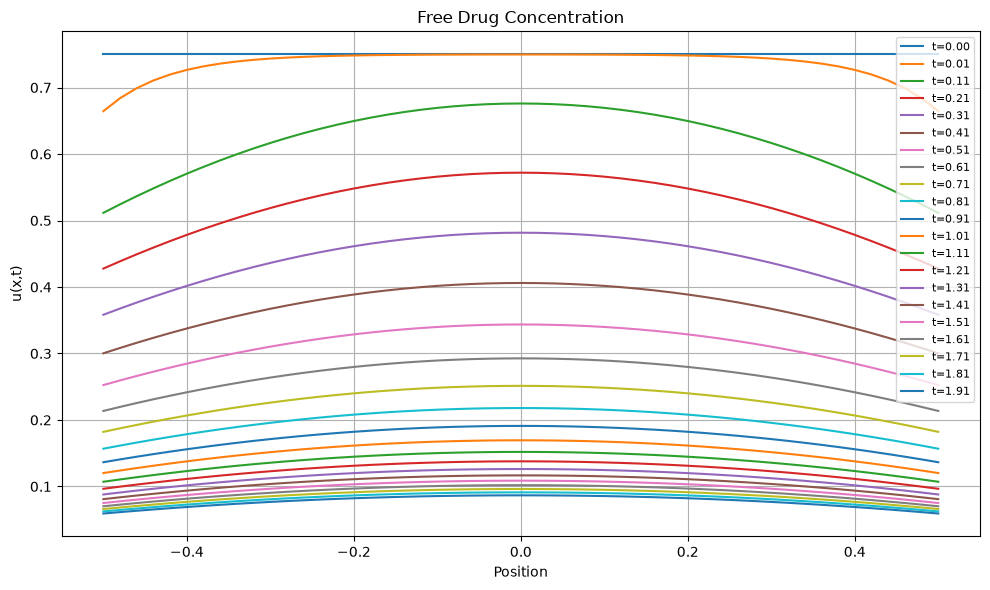

In [84]:
plt.figure(figsize=(10,6))

for i in range(len(time_history)):
    plt.plot(
        x,
        u_history[i],
        label=f"t={time_history[i]:.2f}"
    )

plt.title("Free Drug Concentration")
plt.xlabel("Position")
plt.ylabel("u(x,t)")
plt.grid(True)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

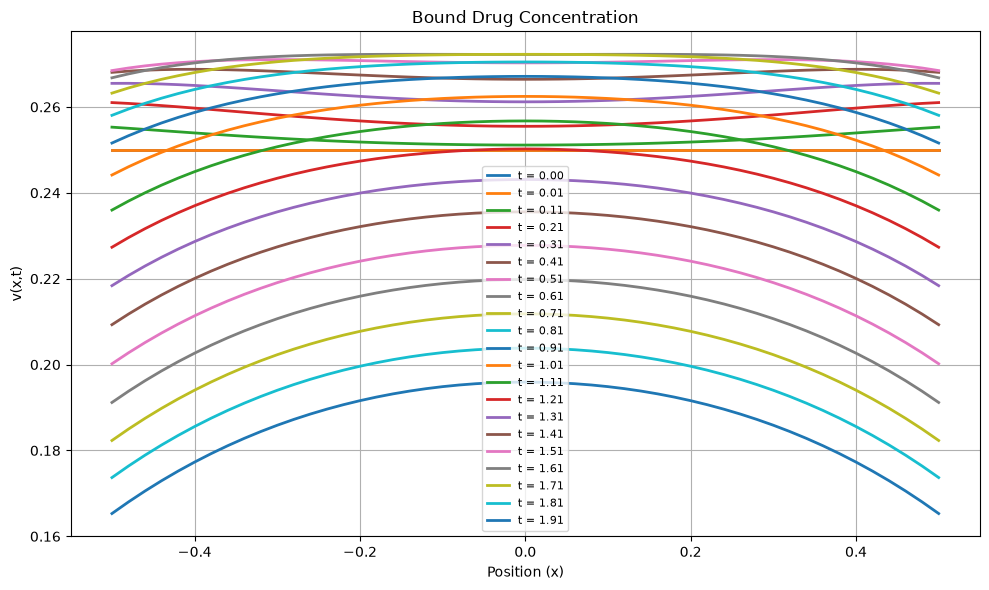

In [87]:
# Plot Bound Drug Concentration

plt.figure(figsize=(10, 6))

for i in range(len(time_history)):
    plt.plot(
        x,
        v_history[i],
        linewidth=2,
        label=f"t = {time_history[i]:.2f}"
    )

plt.title("Bound Drug Concentration")

plt.xlabel("Position (x)")

plt.ylabel("v(x,t)")

plt.grid(True)

plt.legend(loc="best", fontsize=8)

plt.tight_layout()

plt.show()

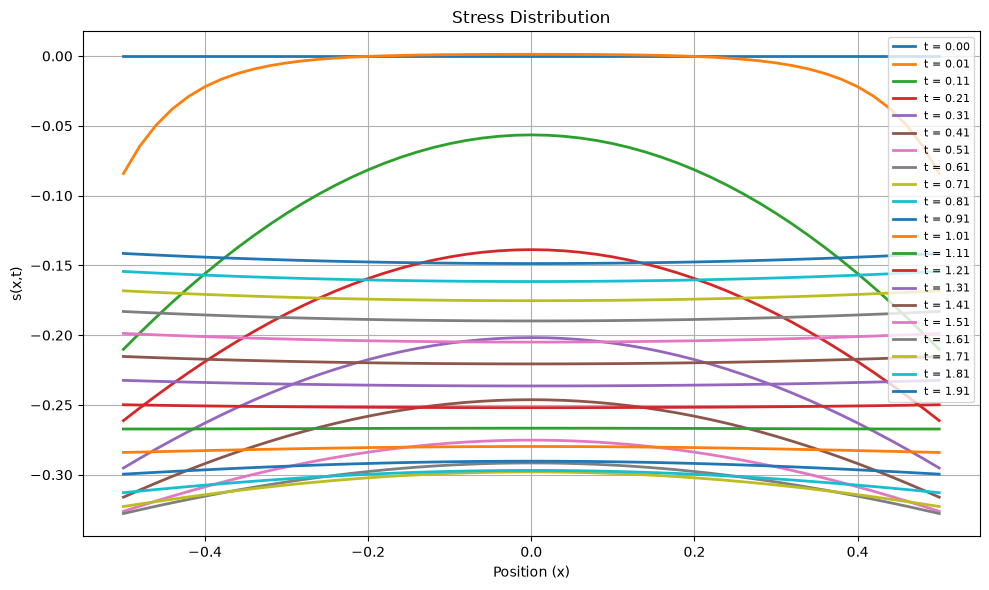

In [88]:
# Plot Stress Distribution

plt.figure(figsize=(10, 6))

for i in range(len(time_history)):
    plt.plot(
        x,
        s_history[i],
        linewidth=2,
        label=f"t = {time_history[i]:.2f}"
    )

plt.title("Stress Distribution")

plt.xlabel("Position (x)")

plt.ylabel("s(x,t)")

plt.grid(True)

plt.legend(loc="best", fontsize=8)

plt.tight_layout()

plt.show()

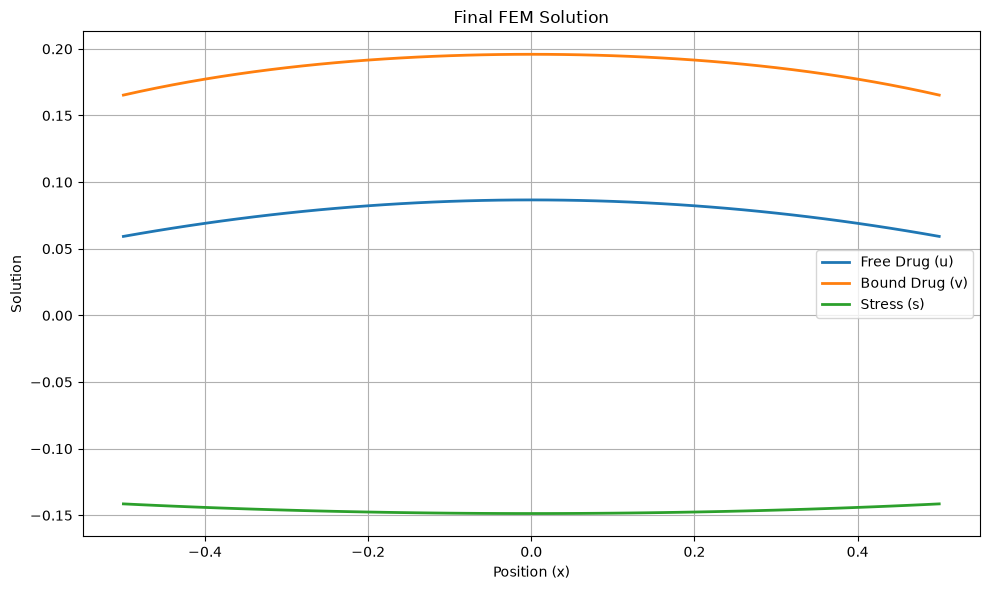

In [89]:
# Final Solution

plt.figure(figsize=(10, 6))

plt.plot(x, u_history[-1], label="Free Drug (u)", linewidth=2)

plt.plot(x, v_history[-1], label="Bound Drug (v)", linewidth=2)

plt.plot(x, s_history[-1], label="Stress (s)", linewidth=2)

plt.xlabel("Position (x)")

plt.ylabel("Solution")

plt.title("Final FEM Solution")

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()